In [4]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train_data = pd.read_csv("bank_train.csv")
test_data = pd.read_csv("bank_test.csv")    # test data without 'y'
print("Train shape:", train_data.shape)
print("Test shape:", test_data.shape)
print(train_data.head())

Train shape: (750000, 18)
Test shape: (250000, 17)
   id  age          job  marital  education default  balance housing loan  \
0   0   42   technician  married  secondary      no        7      no   no   
1   1   38  blue-collar  married  secondary      no      514      no   no   
2   2   36  blue-collar  married  secondary      no      602     yes   no   
3   3   27      student   single  secondary      no       34     yes   no   
4   4   26   technician  married  secondary      no      889     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  y  
0  cellular   25   aug       117         3     -1         0  unknown  0  
1   unknown   18   jun       185         1     -1         0  unknown  0  
2   unknown   14   may       111         2     -1         0  unknown  0  
3   unknown   28   may        10         2     -1         0  unknown  0  
4  cellular    3   feb       902         1     -1         0  unknown  1  


In [6]:
print("Columns:", train_data.columns.tolist())
print("Shape:", train_data.shape)
print(train_data.head())

Columns: ['id', 'age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']
Shape: (750000, 18)
   id  age          job  marital  education default  balance housing loan  \
0   0   42   technician  married  secondary      no        7      no   no   
1   1   38  blue-collar  married  secondary      no      514      no   no   
2   2   36  blue-collar  married  secondary      no      602     yes   no   
3   3   27      student   single  secondary      no       34     yes   no   
4   4   26   technician  married  secondary      no      889     yes   no   

    contact  day month  duration  campaign  pdays  previous poutcome  y  
0  cellular   25   aug       117         3     -1         0  unknown  0  
1   unknown   18   jun       185         1     -1         0  unknown  0  
2   unknown   14   may       111         2     -1         0  unknown  0  
3   unknown   28   may        10     

In [7]:
label_encoder = LabelEncoder()
for col in train_data.select_dtypes(include=['object']).columns:
    if col != 'y':  # avoid target column
        label_encoder.fit(train_data[col])
        train_data[col] = label_encoder.transform(train_data[col])
        if col in test_data.columns:
            test_data[col] = label_encoder.transform(test_data[col])


In [8]:
X_train = train_data.drop(columns=['y'])
y_train = train_data['y']


In [9]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(test_data)


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
y_prob = model.predict_proba(X_test)[:, 1]

# --- Step 8: Create Submission File ---
submission = pd.DataFrame({
    "id": range(750000, 750000 + len(y_prob)),
    "y": y_prob
})

# --- Step 9: Save Submission ---
submission.to_csv("submission_bank_classification.csv", index=False)

print("\n✅ Submission file saved as 'submission.csv'")
print(submission.head())



✅ Submission file saved as 'submission.csv'
       id     y
0  750000  0.00
1  750001  0.21
2  750002  0.00
3  750003  0.00
4  750004  0.06


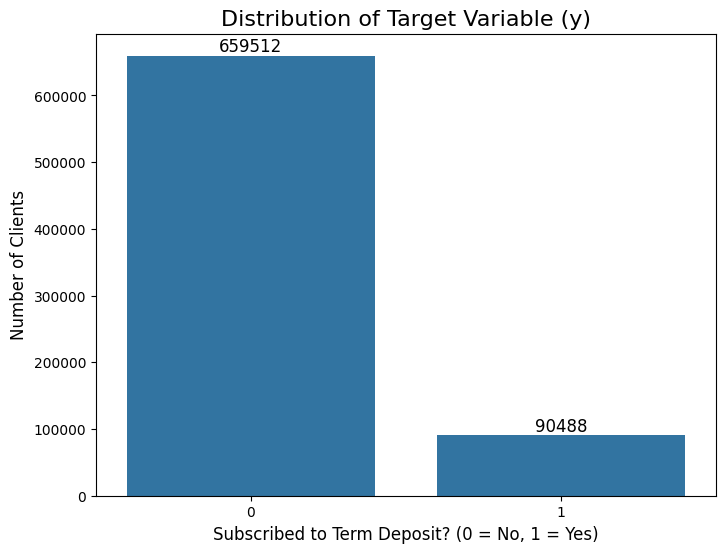

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='y', data=train_data)
plt.title("Distribution of Target Variable (y)", fontsize=16)
plt.xlabel("Subscribed to Term Deposit? (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Number of Clients", fontsize=12)
# Adding annotations to the bars
ax = plt.gca()
for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2., p.get_height(), '%d' % int(p.get_height()), 
            fontsize=12, ha='center', va='bottom')
plt.show()


C:\Users\mrith\AppData\Local\Temp\ipykernel_29436\1947607564.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='job', data=train_data, order=train_data['job'].value_counts().index, palette='viridis')


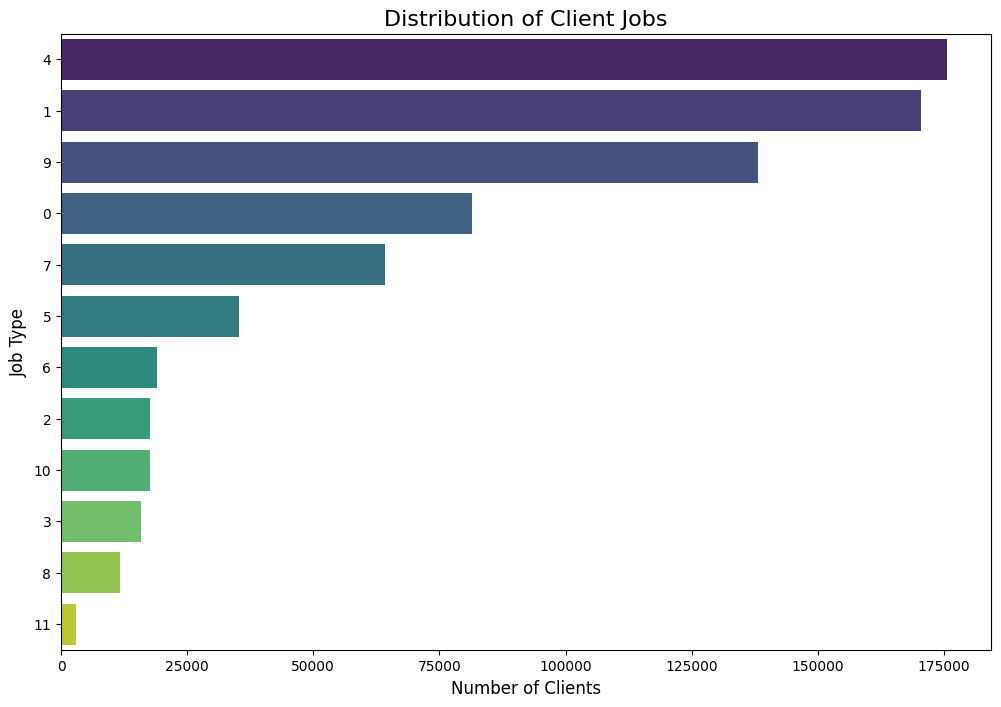

C:\Users\mrith\AppData\Local\Temp\ipykernel_29436\1947607564.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='education', data=train_data, order=train_data['education'].value_counts().index, palette='plasma')


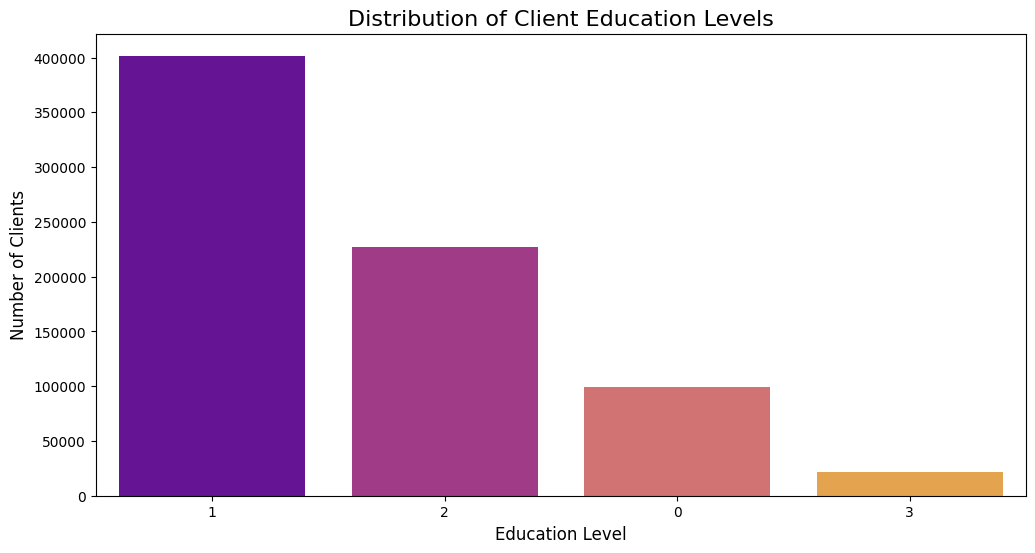

In [17]:
plt.figure(figsize=(12, 8))
sns.countplot(y='job', data=train_data, order=train_data['job'].value_counts().index, palette='viridis')
plt.title('Distribution of Client Jobs', fontsize=16)
plt.xlabel('Number of Clients', fontsize=12)
plt.ylabel('Job Type', fontsize=12)
plt.show()

plt.figure(figsize=(12, 6))
sns.countplot(x='education', data=train_data, order=train_data['education'].value_counts().index, palette='plasma')
plt.title('Distribution of Client Education Levels', fontsize=16)
plt.xlabel('Education Level', fontsize=12)
plt.ylabel('Number of Clients', fontsize=12)
plt.show()

https://www.kaggle.com/competitions/playground-series-s5e8/submissions